In [246]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

In [ ]:
import pandas as pd
import re

logfile = "../spatio-temporal-clustering-benchmark/cakmak_results_complete.csv"


pattern = re.compile(
    r"dataset:\s*(?P<Dataset>[^,]+),\s*"
    r"method:\s*(?P<Algorithm>[^,]+),\s*"
    r"nmi:\s*(?P<NMI>-?\d+\.?\d*),\s*"
    r"ari:\s*(?P<ARI>-?\d+\.?\d*),\s*"
    r"runtime:\s*(?P<Runtime>-?\d+\.?\d*)")

rows = []

with open(logfile, "r") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            rows.append(match.groupdict())

cakmak_df = pd.DataFrame(rows)

# convert numeric columns
cakmak_df["Runtime"] = cakmak_df["Runtime"].astype(float)
cakmak_df["ARI"] = cakmak_df["ARI"].astype(float)
cakmak_df["Algorithm"] = "ST_" + cakmak_df["Algorithm"]
cakmak_df["NMI"] = cakmak_df["NMI"].astype(float)

rename_map = {
    "dataset": "Dataset",
    "algorithm": "Algorithm",
    "method": "Algorithm",
    "runtime": "Runtime",
    "runtim": "Runtime",
    "ari": "ARI",
    "nmi": "NMI"
}


pattern_result = re.compile(
    r"dataset:\s*([^,]+),\s*method:\s*(.*?),\s*ari:\s*([^,]+),\s*nmi:\s*([^,]+),\s*execution time:\s*([0-9\.]+)")

pattern_error = re.compile(
    r"ComputationalError!\s*dataset:\s*([^,]+),\s*method:\s*(.*)$")

competitors = pd.read_csv("00results/runtime_analysis/tslearn_competitors.csv").rename(columns=rename_map)
ship_data = pd.read_csv("00results/runtime_analysis/ship_results_timepoints_thresholdElbow.csv").rename(columns=rename_map)

competitors = competitors[competitors["Algorithm"]=="KShape"]
ship_data = ship_data[ship_data["Matrix"] == "delta+1std"]

#adjust so that runtimes over 200 are set to 200 (for better visualization)
ship_data["Runtime"] = ship_data["Runtime"].apply(lambda x: min(x, 200))
competitors["Runtime"] = competitors["Runtime"].apply(lambda x: min(x, 200))

big = pd.concat([ship_data, competitors], ignore_index=True)

def count_animals(filename):
    file_path = os.path.join(data_folder, filename)  # join path + filename
    if os.path.exists(file_path):
        data = pd.read_csv(file_path)
        return len(data['id'].unique())
    else:
        print(f"Warning: file {file_path} not found")
        return None

data_folder = "../COMET/full_data/"

cakmak_df['Timepoints'] = cakmak_df['Dataset'].str.extract(r'_(\d+)_')[0].astype(float)

cakmak_df['Animals'] = cakmak_df['Dataset'].apply(count_animals)

big = pd.concat([big, cakmak_df], ignore_index=True)

big["Time Points"] = big["Timepoints"]



In [1140]:
big.columns

Index(['Dataset', 'Timepoints', 'Animals', 'Algorithm', 'Matrix', 'Runtime',
       'ARI', 'NMI', 'Time Points'],
      dtype='object')

In [1141]:
import pandas as pd
df = big
# Example: average runtime per algorithm
avg_runtime = df.groupby("Algorithm")["Runtime"].mean().reset_index()

# Get COMET runtime
comet_time = avg_runtime.loc[avg_runtime["Algorithm"] == "COMET", "Runtime"].values[0]

# Compute speedup and percent faster
avg_runtime["Speedup_vs_COMET"] = avg_runtime["Runtime"] / comet_time
avg_runtime["Percent_Faster_vs"] = (avg_runtime["Runtime"] - comet_time) / avg_runtime["Runtime"] * 100

# Sort
avg_runtime = avg_runtime.sort_values("Speedup_vs_COMET", ascending=False)

print(avg_runtime)


          Algorithm    Runtime  Speedup_vs_COMET  Percent_Faster_vs
1            KShape  54.561434         22.834773          95.620714
3          ST_BIRCH  23.702092          9.919679          89.919028
5        ST_HDBSCAN  17.568051          7.352491          86.399167
2  ST_Agglomerative  12.562080          5.257418          80.979255
4         ST_DBSCAN   8.784399          3.676402          72.799491
0             COMET   2.389401          1.000000           0.000000


In [1142]:
avg_runtime.to_clipboard()

## loading in data (old) ##

# VIS

In [1131]:
set(big["Algorithm"].to_list())

{'COMET',
 'KShape',
 'ST_Agglomerative',
 'ST_BIRCH',
 'ST_DBSCAN',
 'ST_HDBSCAN',
 'TS-KMeans',
 'TS-KMeans-DTW'}

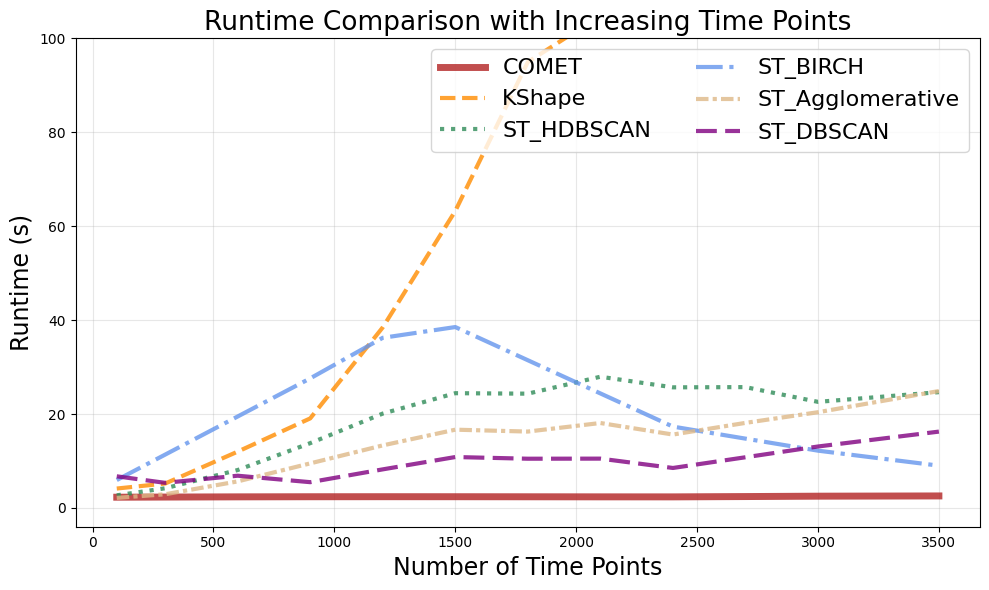

In [1136]:
import matplotlib.pyplot as plt
import pandas as pd

font_size = 16
linewidth_size = 3
sort_by = "Time Points"
feature_of_interest = "Runtime"

if feature_of_interest == "Runtime":
    y_limit = 100
    y_limit_lower = -4
else:
    y_limit = 1
    y_limit_lower = -0.5

methods = [
    "COMET",
    "KShape",
    "ST_HDBSCAN",
    "ST_BIRCH",
    "ST_Agglomerative",
    "ST_DBSCAN",]


rolling_window = 3
default_alpha = 0.8
shade_alpha = 0.2

# Distinct line styles for B/W and colorblind-safe plots
line_styles = {
    "COMET": "-",
    "KShape": "--",
    "ST_HDBSCAN": ":",
    "ST_BIRCH": "-.",
    "ST_Agglomerative": (0, (3, 1, 1, 1)),  # dash-dot-dot
    "ST_DBSCAN": (0, (5, 2)),
}


colors = {
    "COMET": "firebrick",
    "KShape": "darkorange",
    "ST_HDBSCAN": "seagreen",
    "ST_BIRCH": "cornflowerblue",
    "ST_Agglomerative": "burlywood",
    "ST_DBSCAN": "purple"
}


# Filter & reshape data
df_long = big[big["Algorithm"].isin(methods)][
    [sort_by, "Algorithm", feature_of_interest]
]

# Compute mean + std per method × timepoints
grouped = (
    df_long
    .groupby(["Algorithm", sort_by])[feature_of_interest]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(10, 6))

for method in methods:
    subset = grouped[grouped["Algorithm"] == method].sort_values(sort_by)

    # Smooth mean & std
    smooth_mean = subset["mean"].rolling(
        window=rolling_window,
        min_periods=1,
        center=True
    ).mean()

    smooth_std = subset["std"].rolling(
        window=rolling_window + 1,
        min_periods=1,
        center=True
    ).mean()

    plt.plot(
        subset[sort_by],
        smooth_mean,
        color=colors[method],  # Explizit hinzufügen für Sicherheit
        label=method,
        linewidth=linewidth_size+2 if method == "COMET" else linewidth_size,
        alpha=default_alpha,
        linestyle=line_styles.get(method, "-")
    )

    # Shaded std region
    # plt.fill_between(
    # subset[sort_by],
    # smooth_mean - smooth_std,
    # smooth_mean + smooth_std,
    # color=colors[method],
    # alpha=shade_alpha)

plt.ylim(y_limit_lower, y_limit)

plt.xlabel(("Number of "+ sort_by), fontsize=font_size+1)
if feature_of_interest == "Runtime":
    plt.ylabel(feature_of_interest+" (s)", fontsize=font_size+1)
else:
    plt.ylabel(feature_of_interest, fontsize=font_size+1)

plt.title(
    feature_of_interest + " Comparison with Increasing " + sort_by,
    fontsize=font_size + 3
)

plt.grid(True, alpha=0.3)
if feature_of_interest == "ARI" or feature_of_interest == "NMI":
    plt.legend(fontsize=font_size, loc="best",ncol=2)
if feature_of_interest == "Runtime":
    plt.legend(fontsize=font_size, loc="best",ncol=2)
plt.tight_layout()
plt.savefig(
    "figs/" + sort_by + "_comparison_" + feature_of_interest + ".png",
    dpi=300
)
plt.show()


(130, 5)

Model: calovi
  COMET               : 29
  KShape              : 28
  ST_HDBSCAN          : 23
  ST_BIRCH            : 3
  ST_Agglomerative    : 30
  ST_DBSCAN           : 30
(131, 5)

Model: couzin
  COMET               : 28
  KShape              : 23
  ST_HDBSCAN          : 28
  ST_BIRCH            : 5
  ST_Agglomerative    : 30
  ST_DBSCAN           : 30
(121, 5)

Model: reynolds
  COMET               : 28
  KShape              : 25
  ST_HDBSCAN          : 28
  ST_BIRCH            : 4
  ST_Agglomerative    : 30
  ST_DBSCAN           : 30


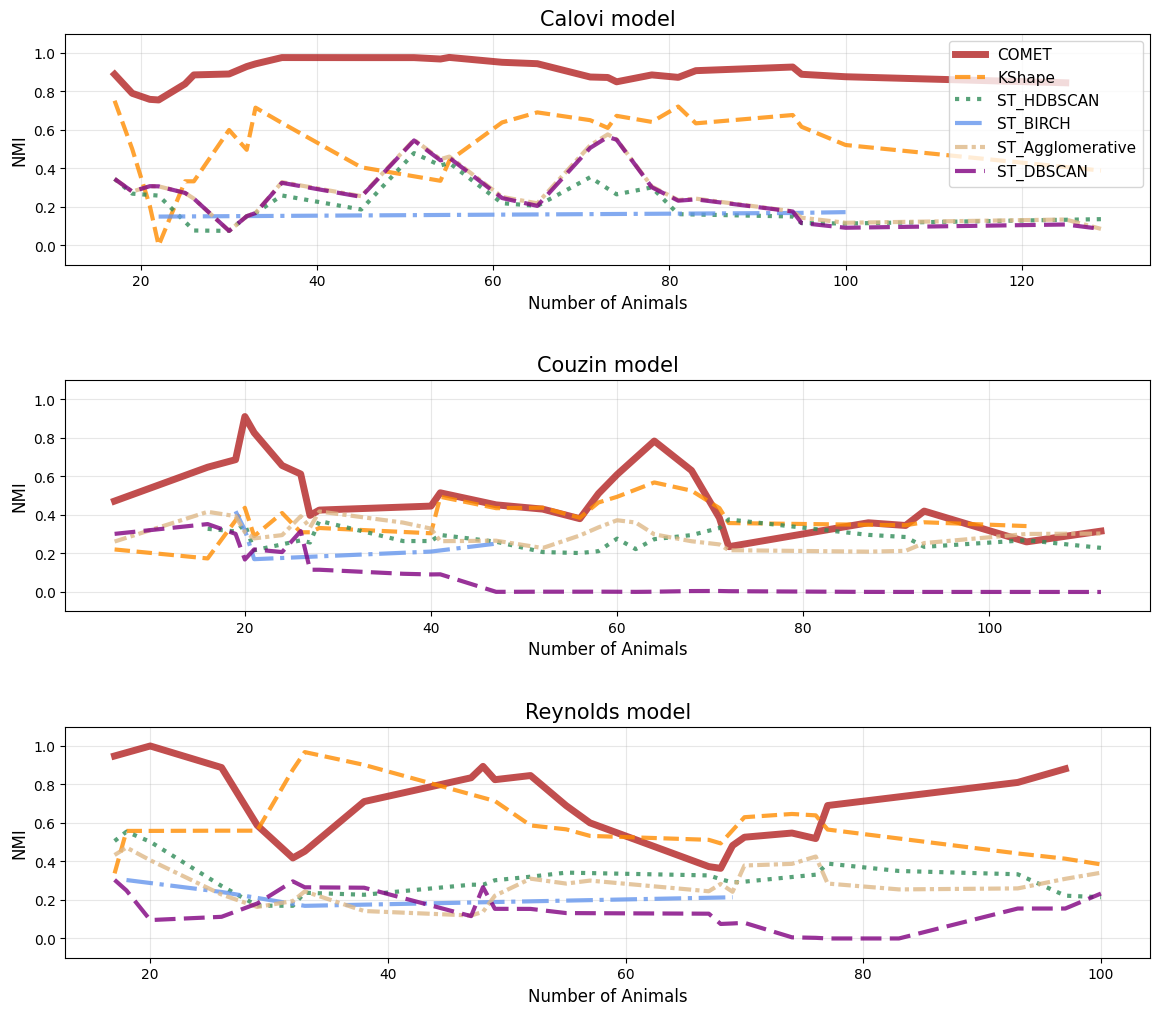

In [471]:
import matplotlib.pyplot as plt

sort_by = "Animals"
feature_of_interest = "NMI"
linewidth_size = 3
font_size = 13

if feature_of_interest == "Runtime":
    y_limit = 50
    y_limit_lower = -0.9
else:
    y_limit = 1.1
    y_limit_lower = -0.1

methods = ["COMET", "KShape","ST_HDBSCAN","ST_BIRCH","ST_Agglomerative","ST_DBSCAN"] 

# Line styles
line_styles = {
    "COMET": "-",
    "KShape": "--",
    "ST_HDBSCAN": ":",
    "ST_BIRCH": "-.",
    "ST_Agglomerative": (0, (3, 1, 1, 1)),
    "ST_DBSCAN": (0, (5, 2)),
}

# Colors
colors = {
    "COMET": "firebrick",
    "KShape": "darkorange",
    "ST_HDBSCAN": "seagreen",
    "ST_BIRCH": "cornflowerblue",
    "ST_Agglomerative": "burlywood",
    "ST_DBSCAN": "purple"
}

rolling_window = 3
default_alpha = 0.8
shade_alpha = 0.2

# Extract model (substring before first "_")
big["Model"] = big["Dataset"].str.extract(r"^([^_]+)")

df_long = big[big["Algorithm"].isin(methods)][[sort_by, "Algorithm", "Model", feature_of_interest]]

counts = (
    df_long
    .groupby(["Model", "Algorithm"])
    .size()
    .reset_index(name="n_results")
)

grouped = (
    df_long
    .groupby(["Algorithm", "Model", sort_by])[feature_of_interest]
    .agg(["mean", "std"])
    .reset_index()
)

models = sorted(grouped["Model"].unique())

# Create figure and axes
fig, axes = plt.subplots(len(models), 1, figsize=(14, 12), sharex=False)
fig.subplots_adjust(hspace=0.5)  # Increase vertical spacing

for i, model in enumerate(models):
    ax = axes[i] if len(models) > 1 else axes  # Handle single subplot

    print(grouped[grouped["Model"] == model].shape)
    print(f"\nModel: {model}")

    model_counts = counts[counts["Model"] == model]

    for method in methods:
        n = model_counts.loc[
            model_counts["Algorithm"] == method,
            "n_results"
        ]
        n = int(n.iloc[0]) if not n.empty else 0
        print(f"  {method:20s}: {n}")

    for method in methods:
        subset = grouped[(grouped["Algorithm"] == method) &
                         (grouped["Model"] == model)].sort_values(sort_by)

        if subset.empty:
            continue

        smooth_mean = subset["mean"].rolling(window=rolling_window, min_periods=1, center=True).mean()
        smooth_std  = subset["std"].rolling(window=rolling_window+1, min_periods=1, center=True).mean()

        ax.plot(
            subset[sort_by],
            smooth_mean,
            color=colors[method],
            label=method,
            linewidth=linewidth_size+2 if method == "COMET" else linewidth_size,
            alpha=default_alpha,
            linestyle=line_styles.get(method, "-")
        )

    ax.set_ylim(y_limit_lower, y_limit)
    ax.set_title(f"{model.capitalize()} model", fontsize=font_size+2)

    if feature_of_interest == "Runtime":
        ax.set_ylabel(feature_of_interest + " (s)", fontsize=font_size-1)
    else:
        ax.set_ylabel(feature_of_interest, fontsize=font_size-1)

    ax.set_xlabel("Number of " + sort_by, fontsize=font_size-1)
    ax.grid(True, alpha=0.3)

    # Show legend only for the first subplot to avoid clutter
    if i == 0:
        ax.legend(fontsize=font_size-2, loc="upper right")

# plt.tight_layout()
plt.savefig(f"figs/{sort_by}_{feature_of_interest}_comparison_by_model.png", dpi=300)
plt.show()


### combined model figures ###


Model: calovi, Feature: NMI
(63, 5)
  COMET               : 29
  KShape              : 28
  ST_HDBSCAN          : 23
  ST_BIRCH            : 3
  ST_Agglomerative    : 30
  ST_DBSCAN           : 30

Model: couzin, Feature: NMI
(64, 5)
  COMET               : 28
  KShape              : 23
  ST_HDBSCAN          : 28
  ST_BIRCH            : 5
  ST_Agglomerative    : 30
  ST_DBSCAN           : 30

Model: reynolds, Feature: NMI
(63, 5)
  COMET               : 28
  KShape              : 25
  ST_HDBSCAN          : 28
  ST_BIRCH            : 4
  ST_Agglomerative    : 30
  ST_DBSCAN           : 30

Model: calovi, Feature: Runtime
(63, 5)
  COMET               : 29
  KShape              : 28
  ST_HDBSCAN          : 23
  ST_BIRCH            : 3
  ST_Agglomerative    : 30
  ST_DBSCAN           : 30

Model: couzin, Feature: Runtime
(64, 5)
  COMET               : 28
  KShape              : 23
  ST_HDBSCAN          : 28
  ST_BIRCH            : 5
  ST_Agglomerative    : 30
  ST_DBSCAN           : 30


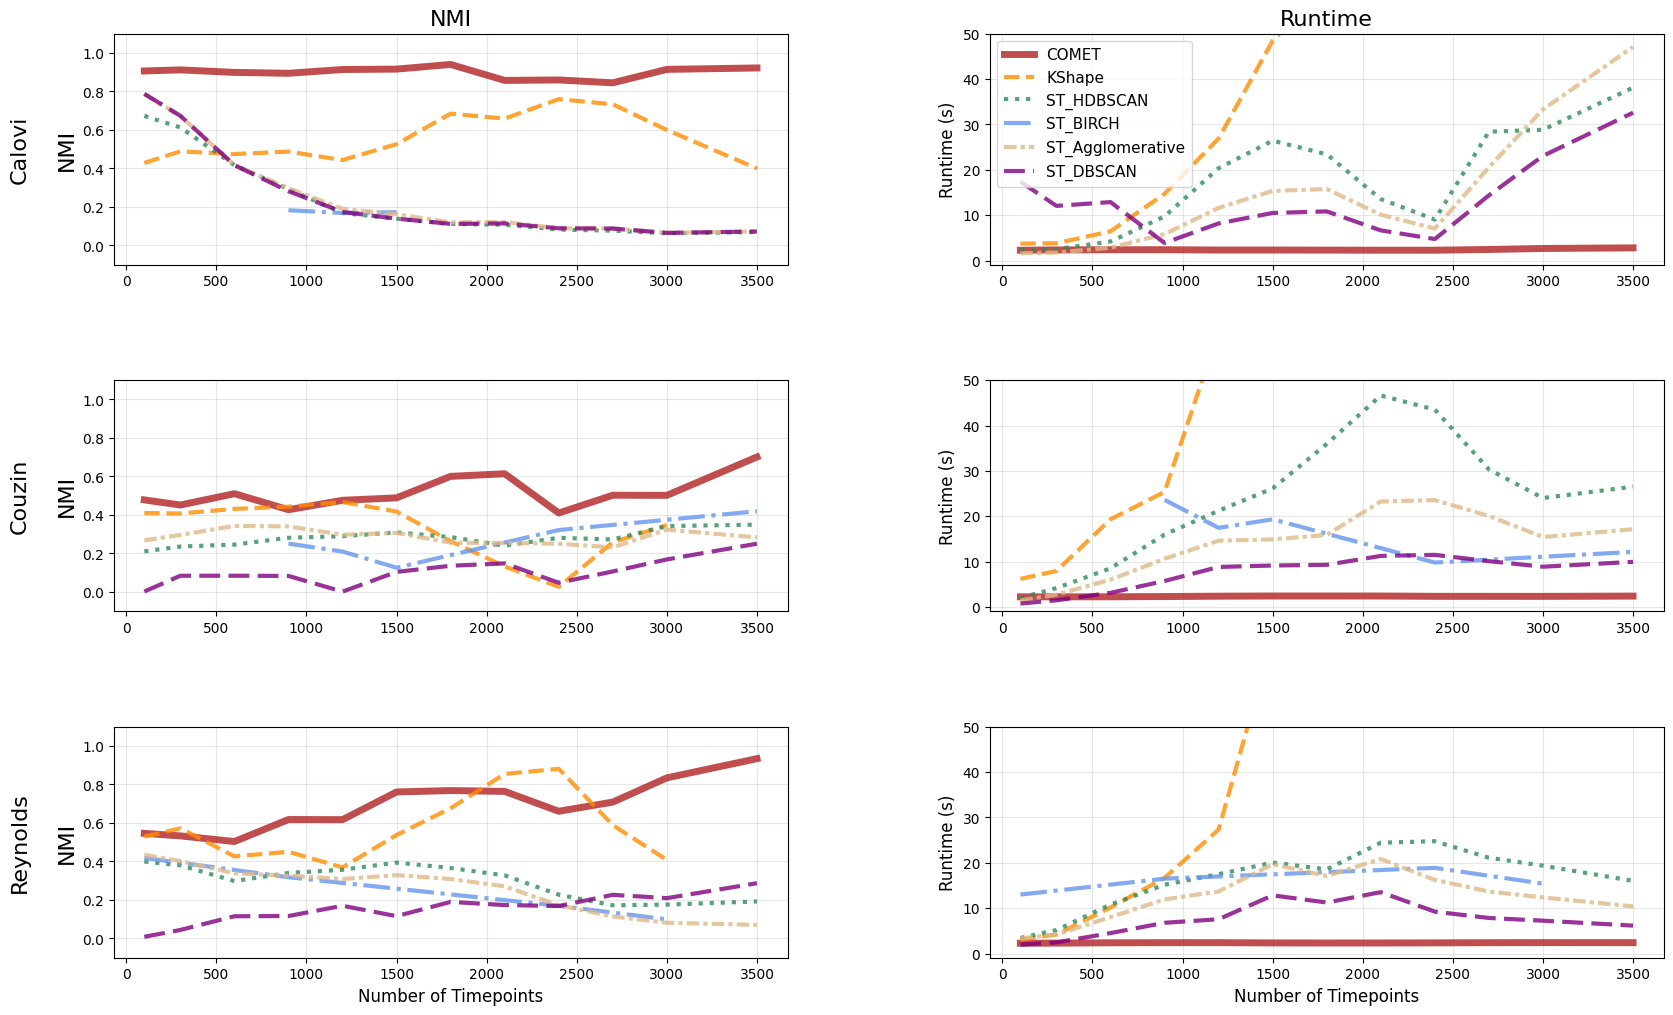

In [ ]:
import matplotlib.pyplot as plt

sort_by = "Timepoints"
linewidth_size = 3
font_size = 17

methods = ["COMET", "KShape","ST_HDBSCAN","ST_BIRCH","ST_Agglomerative","ST_DBSCAN"] 

# Line styles
line_styles = {
    "COMET": "-",
    "KShape": "--",
    "ST_HDBSCAN": ":",
    "ST_BIRCH": "-.",
    "ST_Agglomerative": (0, (3, 1, 1, 1)),
    "ST_DBSCAN": (0, (5, 2)),
}

# Colors
colors = {
    "COMET": "firebrick",
    "KShape": "darkorange",
    "ST_HDBSCAN": "seagreen",
    "ST_BIRCH": "cornflowerblue",
    "ST_Agglomerative": "burlywood",
    "ST_DBSCAN": "purple"
}

rolling_window = 3
default_alpha = 0.8
shade_alpha = 0.2

# Extract model (substring before first "_")
big["Model"] = big["Dataset"].str.extract(r"^([^_]+)")

df_long = big[big["Algorithm"].isin(methods)][[sort_by, "Algorithm", "Model", "Runtime", "NMI"]]

counts = (
    df_long
    .groupby(["Model", "Algorithm"])
    .size()
    .reset_index(name="n_results")
)

models = sorted(df_long["Model"].unique())

# Create figure with 2 columns (NMI on left, Runtime on right)
fig, axes = plt.subplots(len(models), 2, figsize=(20, 12), sharex=False)
fig.subplots_adjust(hspace=0.5, wspace=0.3)  # Adjust spacing

# Loop through each feature
features = ["NMI", "Runtime"]

for feat_idx, feature_of_interest in enumerate(features):
    # Set y-limits based on feature
    if feature_of_interest == "Runtime":
        y_limit = 50
        y_limit_lower = -0.9
    else:
        y_limit = 1.1
        y_limit_lower = -0.1
    
    # Group data for this feature
    grouped = (
        df_long
        .groupby(["Algorithm", "Model", sort_by])[feature_of_interest]
        .agg(["mean", "std"])
        .reset_index()
    )
    
    for i, model in enumerate(models):
        ax = axes[i, feat_idx]  # Select column based on feature
        
        print(f"\nModel: {model}, Feature: {feature_of_interest}")
        print(grouped[grouped["Model"] == model].shape)
        
        model_counts = counts[counts["Model"] == model]
        
        for method in methods:
            n = model_counts.loc[
                model_counts["Algorithm"] == method,
                "n_results"
            ]
            n = int(n.iloc[0]) if not n.empty else 0
            print(f"  {method:20s}: {n}")
        
        for method in methods:
            subset = grouped[(grouped["Algorithm"] == method) &
                             (grouped["Model"] == model)].sort_values(sort_by)
            
            if subset.empty:
                continue
            
            smooth_mean = subset["mean"].rolling(window=rolling_window, min_periods=1, center=True).mean()
            smooth_std  = subset["std"].rolling(window=rolling_window+1, min_periods=1, center=True).mean()
            
            ax.plot(
                subset[sort_by],
                smooth_mean,
                color=colors[method],
                label=method,
                linewidth=linewidth_size+2 if method == "COMET" else linewidth_size,
                alpha=default_alpha,
                linestyle=line_styles.get(method, "-")
            )
        
        ax.set_ylim(y_limit_lower, y_limit)
        
        # Set title for top row only
        if i == 0:
            ax.set_title(f"{feature_of_interest}", fontsize=font_size+3)
        
        # Add model name on the left side
        if feat_idx == 0:
            ax.set_ylabel(f"{model.capitalize()}\n\n{feature_of_interest}", fontsize=font_size+3)
        else:
            if feature_of_interest == "Runtime":
                ax.set_ylabel(feature_of_interest + " (s)", fontsize=font_size-1)
            else:
                ax.set_ylabel(feature_of_interest, fontsize=font_size-1)
        
        # Set x-label for bottom row only
        if i == len(models) - 1:
            ax.set_xlabel("Number of " + sort_by, fontsize=font_size-1)
        
        ax.grid(True, alpha=0.3)
        
        # # Show legend only for the top-right subplot
        # if i == 0 and feat_idx == 1:
        #     ax.legend(fontsize=font_size-2, loc="upper left")

plt.savefig(f"figs/{sort_by}_combined_comparison_by_model.png", dpi=300, bbox_inches='tight')
plt.show()

In [1118]:
import matplotlib.pyplot as plt

sort_by = "Time Points"
linewidth_size = 3
font_size = 17
feature = "ARI"
methods = ["COMET", "KShape","ST_HDBSCAN","ST_BIRCH","ST_Agglomerative","ST_DBSCAN"] 

# Line styles
line_styles = {
    "COMET": "-",
    "KShape": "--",
    "ST_HDBSCAN": ":",
    "ST_BIRCH": "-.",
    "ST_Agglomerative": (0, (3, 1, 1, 1)),
    "ST_DBSCAN": (0, (5, 2)),
}

# Colors
colors = {
    "COMET": "firebrick",
    "KShape": "darkorange",
    "ST_HDBSCAN": "seagreen",
    "ST_BIRCH": "cornflowerblue",
    "ST_Agglomerative": "burlywood",
    "ST_DBSCAN": "purple"
}

rolling_window = 3
default_alpha = 0.8
shade_alpha = 0.2

# Extract model (substring before first "_")
big["Model"] = big["Dataset"].str.extract(r"^([^_]+)")

df_long = big[big["Algorithm"].isin(methods)][[sort_by, "Algorithm", "Model", "Runtime", feature]]

counts = (
    df_long
    .groupby(["Model", "Algorithm"])
    .size()
    .reset_index(name="n_results")
)

models = sorted(df_long["Model"].unique())
features = [feature, "Runtime"]

# -------------------------------
# Plot EACH figure separately
# -------------------------------
for model in models:
    for feature_of_interest in features:

        fig, ax = plt.subplots(figsize=(10, 6))

        if feature_of_interest == "Runtime":
            y_limit = 50
            y_limit_lower = -0.9
        else:
            y_limit = 1.1
            y_limit_lower = -0.1
        print(sort_by)
        grouped = (
            df_long
            .groupby(["Algorithm", "Model", sort_by])[feature_of_interest]
            .agg(["mean", "std"])
            .reset_index()
        )

        for method in methods:
            subset = grouped[
                (grouped["Algorithm"] == method) &
                (grouped["Model"] == model)
            ].sort_values(sort_by)

            if subset.empty:
                continue

            smooth_mean = subset["mean"].rolling(
                window=rolling_window, min_periods=1, center=True
            ).mean()

            smooth_std = subset["std"].rolling(
                window=rolling_window + 1, min_periods=1, center=True
            ).mean()

            ax.plot(
                subset[sort_by],
                smooth_mean,
                color=colors[method],
                label=method,
                linewidth=linewidth_size + 2 if method == "COMET" else linewidth_size,
                alpha=default_alpha,
                linestyle=line_styles.get(method, "-")
            )

        ax.set_ylim(y_limit_lower, y_limit)
        ax.set_title(f"{model.capitalize()} – {feature_of_interest}", fontsize=font_size + 2)
        ax.set_xlabel("Number of " + sort_by, fontsize=font_size+1)

        if feature_of_interest == "Runtime":
            ax.set_ylabel("Runtime (s)", fontsize=font_size+1)
        else:
            ax.set_ylabel(feature_of_interest, fontsize=font_size+1)

        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=font_size+1, loc="best", ncol=2)
        fig_name = "Timepoints"
        plt.savefig(
            f"figs/models_with_legend/{fig_name}_{model}_{feature_of_interest}.png",
            # f"figs/models/{fig_name}_{model}_{feature_of_interest}.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.close()


Time Points
Time Points
Time Points
Time Points
Time Points
Time Points


## create tables ##

In [473]:
import pandas as pd

# Example dataframe
# df = pd.read_csv("your_file.csv")  # if reading from a CSV
df = big
# Group by 'Timepoints' and 'Algorithm', then calculate the mean of 'Algorithm Runtime'
stats_df = df.groupby(['Timepoints', 'Algorithm'])['Runtime'].agg(['mean', 'std']).reset_index()


# Pivot for wide format
wide_df = stats_df.pivot(index='Timepoints', columns='Algorithm')
# Flatten MultiIndex columns
wide_df.columns = [f'{algo}_{stat}' for stat, algo in wide_df.columns]
wide_df = wide_df.reset_index()

In [479]:
df = wide_df[["COMET_mean","KShape_mean","ST_Agglomerative_mean","ST_DBSCAN_mean","ST_HDBSCAN_mean","ST_BIRCH_mean"]]

row_min = df.min(axis=1)
print(row_min)

0     0.165000
1     2.270429
2     2.382156
3     2.431722
4     2.344244
5     2.406225
6     2.419033
7     2.307333
8     2.360300
9     2.401860
10    2.507633
11    2.603333
dtype: float64


In [335]:
df = big[big["Algorithm"].isin(methods)][["Dataset","Model","Timepoints","Animals"]]

# df_long.groupby(["Algorithm", "Model","Animals", sort_by])["Timepoints"].agg(["mean", "std"]).reset_index()

In [336]:
df.sort_values(["Model","Timepoints","Animals"])[["Dataset","Timepoints","Animals","Model"]].drop_duplicates().to_csv("00results/runtime_analysis/cakmak_dataset_overview.csv", index=False)

# MD data vis #

In [1145]:
import pandas as pd

# List of CSV files
csv_files = [
    "data/fspeptide_traj1.csv",
    "data/fspeptide_traj2.csv",
    "data/fspeptide_traj3.csv",
    "data/hiv_1.csv"
]

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    
    # Fill the dataset name for all rows
    # Assumes column name is 'dataset'
    df['dataset'] = df['dataset'].ffill().bfill()
    
    dfs.append(df)

# Combine all DataFrames
combined_df = pd.concat(dfs, ignore_index=True)
combined_df.to_csv("data/all_md.csv")


/var/folders/tb/mtqjrwzn04v2ws67ymnhmv5h0000gp/T/ipykernel_98316/3331516495.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


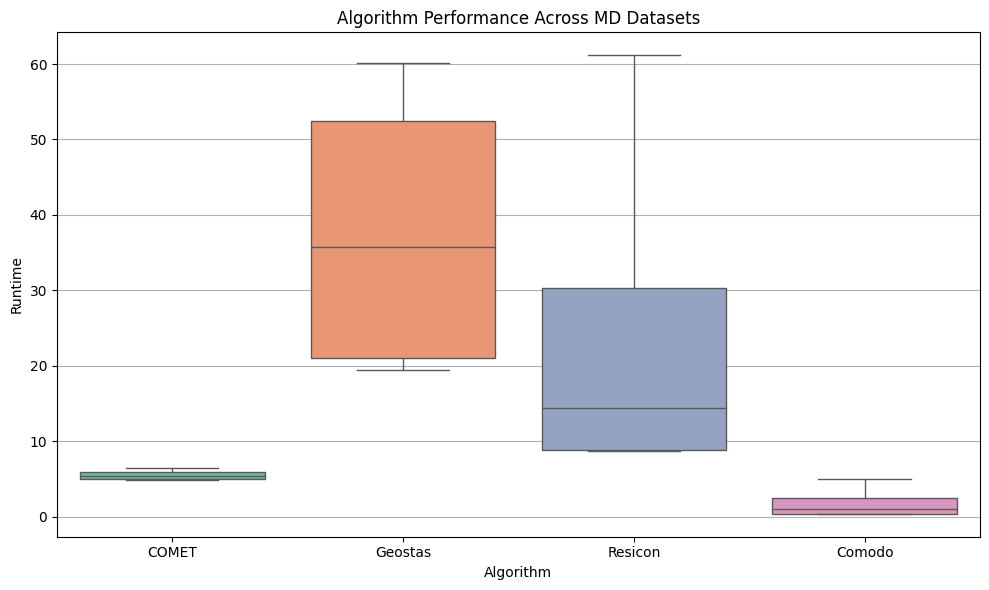

In [1158]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# plt.figure(figsize=(8, 5))
sns.boxplot(
    data=combined_df,
    x="name",
    y="runtime",      # replace with your metric column
    palette="Set2"
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.ylabel("Runtime")
plt.xlabel("Algorithm")
plt.title("Algorithm Performance Across MD Datasets")
plt.grid(axis="y")

# Tight layout
plt.tight_layout()
plt.savefig("figs/runtime_all_datasets.png", dpi=300)
plt.show()




# check std performance #

In [1080]:
matrix1 = "00results/runtime_analysis/simulations/simulation5_ablation_COMET.csv"
# matrix1 = "00results/runtime_analysis/cakmak_ablation_COMET.csv"

ship_ablation1 = pd.read_csv(matrix1)
ship_ablation1 = ship_ablation1.drop_duplicates(["Dataset","Matrix"])

# ship_ablation2 = pd.read_csv(matrix2)
# ship_ablation2 = ship_ablation2.drop_duplicates(["Dataset","Matrix"])

# ship_ablation = pd.concat([ship_ablation1,ship_ablation2])

ship_ablation = ship_ablation1
# ship_ablation = pd.read_csv("00results/runtime_analysis/simulation7_ablation_COMET.csv")
# ship_ablation = ship_ablation.drop_duplicates(["Dataset","Matrix"])

feature = "NMI"
best = (
    ship_ablation[ship_ablation[feature] == ship_ablation.groupby('Dataset')[feature].transform('max')]
    [['Dataset', 'Matrix', feature]]
    .sort_values(['Dataset', feature], ascending=[True, False]))

ship_ablation["Number of Objects"] = ship_ablation["Timepoints"]
ship_ablation["Trajectory length"] = ship_ablation["Trajectories"]
ship_ablation = ship_ablation.replace("delta+1std", "Delta+std")
ship_ablation = ship_ablation.replace("delta", "Delta")
ship_ablation = ship_ablation.replace("stddv","Stand. dev")
print(ship_ablation.shape)

(141, 10)


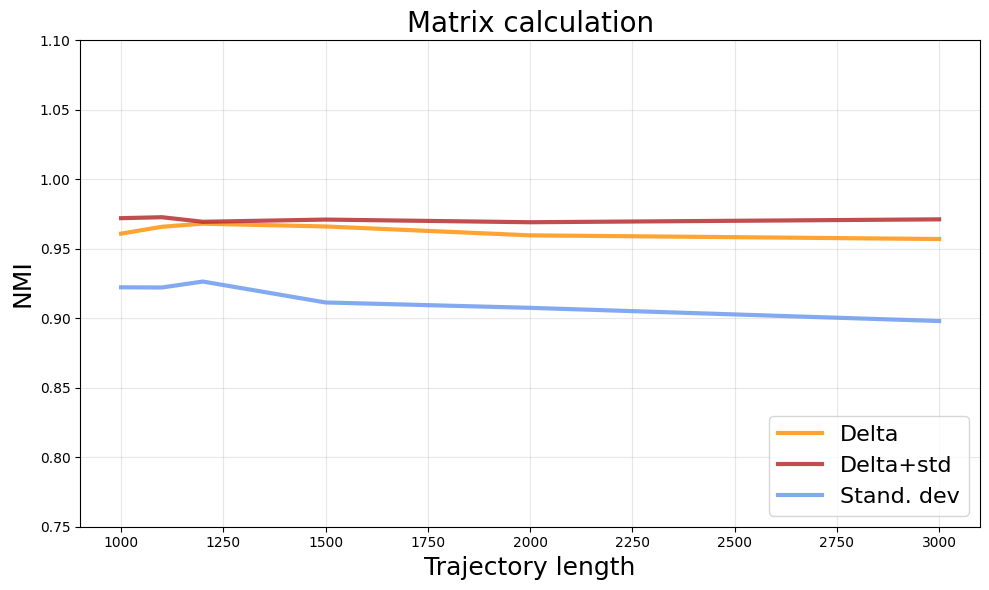

In [1085]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

font_size = 16
linewidth_size = 3
sort_by = "Number of Objects"  # or "Animals" 
sort_by = "Trajectory length"  # or "Animals" 
feature_of_interest = "NMI"  # switch to "NMI" for second plot

# Your color palette from before
colors = {
    "Delta+std": "firebrick",       # e.g., "DTW", "Euclidean" - adjust names
    "Delta": "darkorange",  # replace with actual matrix values
    "Stand. dev": "cornflowerblue"
}

if feature_of_interest == "Runtime":
    y_limit = 4
    y_limit_lower = -0.1
else:  # NMI
    y_limit = 1.1
    y_limit_lower = 0.75

rolling_window = 3
default_alpha = 0.8
shade_alpha = 0.2

df = ship_ablation
matrix_values = df['Matrix'].unique()  # Gets ['DTW', 'Euclidean'] automatically
methods = matrix_values.tolist()

plt.figure(figsize=(10, 6))

# Group by Matrix, Algorithm (optional), and sort_by
for matrix_type in matrix_values:
    # Filter for this matrix type
    df_filtered = df[df['Matrix'] == matrix_type]
    
    # Group by sort_by (Timepoints/Animals) and optionally Algorithm
    grouped = (df_filtered.groupby([sort_by, 'Algorithm'])[feature_of_interest]
              .agg(['mean', 'std']).reset_index())
    
    # Or average across algorithms for Matrix comparison only:
    grouped_simple = (df_filtered.groupby(sort_by)[feature_of_interest]
                     .agg(['mean', 'std']).reset_index())
    
    subset = grouped_simple.sort_values(sort_by)  # Use simple version for clarity
    
    # Smooth
    smooth_mean = subset["mean"].rolling(window=rolling_window, min_periods=1, center=True).mean()
    smooth_std = subset["std"].rolling(window=rolling_window + 1, min_periods=1, center=True).mean()
    
    # Plot
    plt.plot(subset[sort_by], smooth_mean, 
             label=f"{matrix_type}", 
             color=colors.get(matrix_type, 'gray'),
             linewidth=linewidth_size, alpha=default_alpha)
    
    # plt.fill_between(subset[sort_by], smooth_mean - smooth_std, 
    #                 smooth_mean + smooth_std, 
    #                 color=colors.get(matrix_type, 'gray'), alpha=shade_alpha)

plt.ylim(y_limit_lower, y_limit)
plt.xlabel(f"{sort_by}", fontsize=font_size+2)
plt.ylabel(feature_of_interest, fontsize=font_size+2)
plt.title(f"Matrix calculation", fontsize=font_size + 4)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=font_size, loc="upper right" if feature_of_interest == "Runtime" else "lower right")
plt.tight_layout()
plt.savefig(f"figs/matrix_comparison_{sort_by}_{feature_of_interest}.png", dpi=300)
plt.show()
